<a href="https://colab.research.google.com/github/victoria-riley-barnett/intermediate-ml/blob/main/00_foundations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 0: Foundations

This is the reference file for how we think about math in CSC 411: the early Python and library functions behind our first model, and the algorithms they entail. Work it through once as the week-0 practical lab; keep it to return to.

This course asks you to code, to work with data, and to reason about models mathematically. You do not need to arrive fluent in all three, but you do need to be willing to learn and practice.

Some of the math in this course may sit beyond what you remember, or beyond what you were formally taught. That position is expected: this is likely your first class that applies complex math across disciplines, using algorithms, functions, and methods that may exceed immediate recollection. Here is the good and bad news: this is exactly the position a programmer holds toward the symbolic logic of a program. You use it practically, to produce an effect, and only later, through repetition or through the necessity of your own work, does a function start to deepen.

We won't abandon the math that underpins a critical, scientific understanding of applying our Machine Learning models. But we won't get hung up on reproducing every algorithm by hand. Instead we will learn them by utility: a sequence of a specific set of algorithms that are topical to the contemporary history of machine learning, that also remain relevant to the current state of the field. We will learn them by applying them and by reasoning about their effects on data.

## Notebooks:

A Jupyter notebook is a sequence of cells. A cell is either code or markdown. Code cells contain Python and run when you press shift-enter. Markdown cells contain text, like the one you are reading now. Double-click it to see the source.

Code cells run in order and share state. A variable defined in cell 3 is available in cell 7. This means you can build something across cells, but it also means order matters. If you skip a cell and later code relies on it, you get a `NameError`.

In [ ]:
# This is a code cell. Run it.
x = 3
print(f"x is {x}")

x is 3


In [ ]:
# x is still here; cells share state.
y = x + 4
y

7

Restart the kernel and run all cells before you turn anything in. This ensures your notebook runs from a clean state, and that you haven't relied on variables or imports from previous runs.

If you have used R Markdown or MATLAB Live Scripts, the idea is the same.

## A table

A dataset is a table: rows and columns, like a spreadsheet. In Python, a table is a `DataFrame`.

In [ ]:
import pandas as pd
import seaborn as sns

penguins = sns.load_dataset('penguins')
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


Underneath, the table is built from NumPy arrays: grids of numbers, all of the same type. NumPy is the numeric engine of the Python stack: pandas wraps it for tabular data, and the libraries we use later build models from it. We focus on pandas and NumPy for the initial tooling because they are foundational to the Python ecosystem, and they let us reach the most important concepts in machine learning without getting lost in more complex libraries until those libraries are net saving us time.

You manipulate the table by asking it to do things to itself. `penguins.head()` means "table, show your first rows." This "reading the dot" habit is the shape of everything in Python: `object.method()` reads as "object, do method to your own data." The object before the dot supplies the data; the method acts on exactly that data.

A function is the same idea without the object: a named block of code that takes arguments and returns a result.

In [ ]:
def square(x):
    return x * x

square(7)

49

A function does one job, takes its inputs as arguments, and returns its output. Avoid functions that read or change variables defined outside themselves; they make code hard to reason about and harder to debug. The most critical thing in machine learning is to be able to reason about the flow of data through a model; functions that rely on outside state make that reasoning difficult.

A loop does the same thing to every member of a sequence.

In [ ]:
for name in ['alice', 'bob', 'carol']:
    print(name.title())

Alice
Bob
Carol


A list comprehension is the short way to build a list from a sequence: a Pythonic loop that builds a list, something we'll do a lot. The general form is `[<expression> for <variable> in <sequence>]`, with an optional `if` clause to filter: `[x**2 for x in range(5) if x % 2 == 0]` produces `[0, 4, 16]`.

In [ ]:
[square(i) for i in range(5)]

[0, 1, 4, 9, 16]

Read left to right: "square of i, for each i in range(5)."

Your table can summarize itself. `.describe()` computes one statistic per column, a number that compresses the whole column:

In [ ]:
penguins.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


A row of `describe()` is a statistic. `count` is the number of non-missing values, `mean` the average; you met it in statistics class, probably called it the mean there too. `std` is the standard deviation, how far the numbers spread around the mean: wide `std`, wide spread; narrow `std`, tight cluster. The min, quartiles, and max sketch the column's shape. Pick up the standard deviation. It's the width of the data, and it does a lot of the work in the math of this course.

Methods chain: each one returns a new object you can call the next one on.

In [ ]:
penguins.dropna().groupby('species').mean(numeric_only=True)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.823973,18.347260,190.102740,3706.164384
Chinstrap,48.833824,18.420588,195.823529,3733.088235
Gentoo,47.568067,14.996639,217.235294,5092.436975


`dropna()` removes rows with missing values and returns a DataFrame. `groupby('species')` splits the data into groups. `mean()` averages each numeric column per group and returns a DataFrame. Each dot is a method call on whatever the previous step returned.

matplotlib draws plots. It makes the table visible.

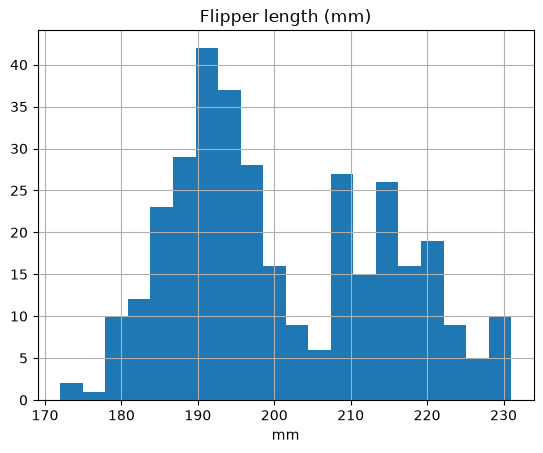

In [ ]:
import matplotlib.pyplot as plt

penguins['flipper_length_mm'].hist(bins=20)
plt.title('Flipper length (mm)')
plt.xlabel('mm');

A histogram bins values and counts how many fall in each bin. If you have made a chart in Excel or Google Sheets, this is the same operation: select a column, choose a chart type, label the axes.

This tabular-to-multidimensional transition is a core perspective at this intermediate level of machine learning. It usually helps students understand the difference between data and models, and what the models are doing to the data.

## A column

Take one column of the table. It is an ordered list of numbers, one per row, always in the same order. It is the simplest shape in this course. Statistics calls this a variable, Python calls it a list, but linear algebra calls it a **vector**.

In [ ]:
import numpy as np

v = np.array([1.0, 2.0, 3.0])
v

array([1., 2., 3.])

A vector is a mathematical object with magnitude and direction. In machine learning, vectors represent data points in a multi-dimensional space, feature vectors in a problem space. We are trying to find patterns in data relevant to a specific problem; the solution gives us the direction to set out in. Much of the field is trying to find the best direction to move in a high-dimensional space to optimize some objective.

A column of a DataFrame is a vector. A row of pixel intensities from an image is a vector. A sentence converted to word counts is a vector. Each position means something specific, and the order never changes. That is what makes a list of numbers a vector rather than a pile.

When an equation uses a bold letter like **x**, it means a vector. When it uses a capital letter like **W**, it usually means a matrix, a grid of numbers with vectors stacked side by side.

## The rules

So much for what a column is. What can you do with one?

### Element-wise: same position, pair by pair

In [ ]:
a = np.array([1.0, 2.0, 3.0])
b = np.array([4.0, 5.0, 6.0])
a + b, a * b, a @ b

(array([5., 7., 9.]), array([ 4., 10., 18.]), np.float64(32.0))

`a + b` and `a * b` are element-wise: matching positions combined one pair at a time. This is a common move you do in a spreadsheet when a column of prices meets a column of quantities and you fill a third column with the products.

### The dot product: multiply matching slots, then add

Take two lists of the same length. Multiply the first number in each, the second number in each, and so on, then add up all those products:

```
u = [a, b, c]
v = [x, y, z]
dot(u, v) = a*x + b*y + c*z
```

In NumPy or PyTorch you write `u @ v`.

In [ ]:
u = np.array([1., 2., 3.])
v = np.array([4., 5., 6.])
u @ v    # 1*4 + 2*5 + 3*6 = 32

np.float64(32.0)

The dot product is a core operation in linear algebra, and will be important for us to conceptualize. It is only defined for vectors of the same length. You cannot take the dot product of a 3-dimensional vector and a 2-dimensional one. In general, it measures how much two vectors point in the same direction.

The result is large when the two vectors have similar numbers in the same positions, and small, or negative, when they disagree. Think of each position as a feature and each number as how strongly that feature is present: the dot product is a weighted agreement score. If you have used `SUMPRODUCT` in a spreadsheet, you have done exactly this: multiply matching cells down two columns, then sum.

Comparing two documents makes it concrete. Suppose document A uses the words "gradient," "descent," and "loss" and document B uses "gradient," "ascent," and "profit." Build a word-count vector for each, one entry per word in the combined vocabulary, a 1 if the word appears, a 0 if it doesn't:

```
         gradient  descent  loss  ascent  profit
vec(A) =    1         1       1      0       0
vec(B) =    1         0       0      1       1
```

The dot product: `(1×1) + (1×0) + (1×0) + (0×1) + (0×1) = 1`. One shared term. Change the words and the score moves.

A neural network layer is a dot product followed by a nonlinearity. Every classifier you build in this course turns on this operation.

## The grid

Stack columns side by side and you get the table back, only now it is called a **matrix**, and it comes with rules of its own. A matrix is a grid of numbers: a NumPy array with two dimensions. A DataFrame is a matrix with names attached.

In [ ]:
A = np.array([[1, 2, 3],
              [4, 5, 6]])        # (2, 3)
B = np.array([[1, 0],
              [0, 1],
              [1, 1]])           # (3, 2)
A @ B                            # (2, 2)

array([[ 4,  5],
       [10, 11]])

Matrix multiplication is FOIL with more terms. You know the move as `(a + b)(c + d) = ac + ad + bc + bd`, where each term in the first parentheses touches each term in the second. If A is `(m × n)` and B is `(n × p)`, the product C is `(m × p)`. Each cell `C[i, j]` is the dot product of row `i` of A with column `j` of B. Every row touches every column.

The inner dimensions must match: the number of columns in A must equal the number of rows in B. A `(3, 4)` times a `(4, 2)` works and gives a `(3, 2)`. A `(4, 2)` times a `(3, 4)` is an error, because the inner dimensions 2 and 3 don't match.

Trace one cell: `C[0, 1]` is the dot product of row 0 of A (`[1, 2, 3]`) and column 1 of B (`[0, 1, 1]`), which is `1*0 + 2*1 + 3*1 = 5`. The top-right cell of the output.

### The shape of a prediction

A line is `y = m*x + b`. `m` is the slope: how much `y` changes when `x` increases by 1. `b` is the intercept: the value of `y` when `x` is 0.

In [ ]:
def line(x, m, b):
    return m * x + b

line(x=2, m=3, b=1)   # 3*2 + 1 = 7

7

Change `m` and the line tilts; change `b` and it shifts up or down. Much of this course is a line with more inputs: many `x`'s instead of one, a vector of slopes, one intercept. A prediction is a weighted sum plus a constant, the dot product from the last section plus an added number. A neural network layer is this operation repeated in parallel many times.

## The stack

A tensor is an array with any number of dimensions. The rank of a tensor is the number of dimensions it has; the shape is a tuple of integers giving the size along each dimension. A scalar is a tensor of rank 0, a vector is a tensor of rank 1, a matrix is a tensor of rank 2, and it keeps going. An image is rank 3: rows × columns × colors. A batch of tables is rank 3: tables × rows × columns. Same rules, more indices.

That is the linear algebra this course builds on: vectors, matrices, dot products, matrix multiplication, and the idea of rank. The rest of the course adds rules on top of these. It never replaces them.

## Models are objects

In [ ]:
class Counter:
    def __init__(self, start=0):
        self.count = start

    def bump(self):
        self.count += 1

    def reset(self):
        self.count = 0

A class is a blueprint for an object: it names what data the object holds and what operations are allowed to touch that data. Here we want a Counter that always has a count it can bump and reset, and we want many instances. `__init__` sets up the data with a default value; each instance has its own copy. `bump` and `reset` are methods, functions attached to the instance. `self` means "this specific instance."

Two counters hold separate counts. Calling a method on one does not affect the other.

In [ ]:
c1 = Counter()
c2 = Counter(start=100)
c1.bump()
c2.bump()
c1.count, c2.count

(1, 101)

Every library this course leans on hands you objects built this way. A pandas DataFrame is a class; `df.mean()` is a method call. A PyTorch module is a class; `model.fit(X, y)` is a method call. The same pattern, data bundled with the operations that work on it, is behind everything we use.

**Two names, one object.** `df2 = df` does not create a new DataFrame. It gives the same object a second name. Mutate through either name and both see the change.

In [ ]:
import pandas as pd
df = pd.DataFrame({'a': [1, 2, 3]})
df2 = df
df2['a'] = 0
df

,a
0,0
1,0
2,0


Use `.copy()` when you need an independent copy.

In [ ]:
df3 = df.copy()
df3['a'] = 99
df.a.tolist(), df3.a.tolist()

([0, 0, 0], [99, 99, 99])

**Make.** Write a `Wallet` class. It holds a balance. `deposit(amount)` adds to it. `withdraw(amount)` subtracts, but raises a `ValueError` if the balance would go below zero.

In [ ]:
# Your Wallet class here

In [ ]:
w = Wallet()
w.deposit(50)
w.withdraw(20)
w.balance          # should be 30

In [ ]:
w.withdraw(100)    # should raise ValueError

## Check yourself

1. **Notebook.** Restart the kernel and run all cells. Does the `square` function work in the cell after the one that defined it? Why?

2. **Libraries.** Load the `diamonds` dataset from seaborn (`sns.load_dataset('diamonds')`). Plot a histogram of `price`. What is the mean price by `cut`?

3. **Math.** Without running it: what shape does a `(5, 3)` matrix times a `(3, 1)` matrix produce? Verify in NumPy.